Please credit the original work by AHMED SHAHRIAR SAKIB (@ahmedshahriarsakib) https://www.kaggle.com/code/ahmedshahriarsakib/bangladesh-medicine-analytics

In [1]:
import os

if not os.path.exists('data/medicine.csv'):
    !pip install -q kaggle
    !kaggle datasets download -d ahmedshahriarsakib/assorted-medicine-dataset-of-bangladesh --unzip -p data/
else:
    print("Dataset already exists, skipping download.")

Dataset already exists, skipping download.


# **Medicine Analytics**

# **Introduction**
In this project, the medicine data from Bangladesh are explored, and some data cleaning are performed.

### Dataset Source :
>#### [Assorted Medicine Dataset of Bangladesh](https://www.kaggle.com/ahmedshahriarsakib/assorted-medicine-dataset-of-bangladesh)

### Check the GitHub project below if you want to know more about the scraping process. I created a scrapy-django integrated REST API that scrapes the medicine data, transform them ( as per the model desing) and load it to PostgreSQL db
>### [https://github.com/ahmedshahriar/bd-medicine-scraper](https://github.com/ahmedshahriar/bd-medicine-scraper)

### If you like the dataset please use it on your project and share

# **Libraries and Configurations**

In [2]:
import re
import warnings

import pandas as pd
import numpy as np

import plotly.express as px
from plotly.offline import init_notebook_mode, iplot

import matplotlib.pyplot as plt

from wordcloud import WordCloud, STOPWORDS # generate wordcloud
from bs4 import BeautifulSoup # clean html texts
from IPython.display import Markdown, display

def print_markdown(string):
    display(Markdown(string))



warnings. filterwarnings('ignore')


pd.set_option('display.max_column', None)
pd.set_option('display.max_colwidth', 60)
# pd.set_option("display.max_colwidth", -1)

init_notebook_mode(connected=True) # to display plotly graph offline

%matplotlib inline

print("Libraries imported and configurations set.")

Libraries imported and configurations set.


# **Medicine**

In [3]:
# Note: The symbol in price columns is the Bangladeshi Taka (BDT) currency symbol
df_medicine = pd.read_csv('data/medicine.csv', encoding = "utf-8")
print(f"Loaded medicine.csv: {df_medicine.shape[0]} rows, {df_medicine.shape[1]} columns.")

Loaded medicine.csv: 21714 rows, 10 columns.


In [4]:
df_medicine.head()

,brand id,brand name,type,slug,dosage form,generic,strength,manufacturer,package container,Package Size
0,4077,A-Cold,allopathic,a-coldsyrup4-mg5-ml,Syrup,Bromhexine Hydrochloride,4 mg/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 40.12,NaN
1,4006,A-Cof,allopathic,a-cofsyrup10-mg30-mg125-mg5-ml,Syrup,Dextromethorphan + Pseudoephedrine + Triprolidine,(10 mg+30 mg+1.25 mg)/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 100.00,NaN
2,6174,A-Clox,allopathic,a-cloxinjection500-mgvial,Injection,Cloxacillin Sodium,500 mg/vial,ACME Laboratories Ltd.,"500 mg vial: ৳ 28.43,(5's pack: ৳ 142.15),",(5's pack: ৳ 142.15)
3,6173,A-Clox,allopathic,a-cloxinjection250-mgvial,Injection,Cloxacillin Sodium,250 mg/vial,ACME Laboratories Ltd.,"250 mg vial: ৳ 20.00,(5's pack: ৳ 100.00),",(5's pack: ৳ 100.00)
4,6172,A-Clox,allopathic,a-cloxpowder-for-suspension125-mg5-ml,Powder for Suspension,Cloxacillin Sodium,125 mg/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 45.00,NaN


In [5]:
df_medicine.shape

(21714, 10)

In [6]:
df_medicine.columns

Index(['brand id', 'brand name', 'type', 'slug', 'dosage form', 'generic',
       'strength', 'manufacturer', 'package container', 'Package Size'],
      dtype='str')

We don't need `brand id` column as well as `slug` column, let's drop them both.

In [7]:
df_medicine.drop(["brand id","slug"],axis=1, inplace=True)
print("Dropped 'brand id' and 'slug' columns from medicine data.")

Dropped 'brand id' and 'slug' columns from medicine data.


# **Descriptive Analysis**

In [8]:
df_medicine.head()

,brand name,type,dosage form,generic,strength,manufacturer,package container,Package Size
0,A-Cold,allopathic,Syrup,Bromhexine Hydrochloride,4 mg/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 40.12,NaN
1,A-Cof,allopathic,Syrup,Dextromethorphan + Pseudoephedrine + Triprolidine,(10 mg+30 mg+1.25 mg)/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 100.00,NaN
2,A-Clox,allopathic,Injection,Cloxacillin Sodium,500 mg/vial,ACME Laboratories Ltd.,"500 mg vial: ৳ 28.43,(5's pack: ৳ 142.15),",(5's pack: ৳ 142.15)
3,A-Clox,allopathic,Injection,Cloxacillin Sodium,250 mg/vial,ACME Laboratories Ltd.,"250 mg vial: ৳ 20.00,(5's pack: ৳ 100.00),",(5's pack: ৳ 100.00)
4,A-Clox,allopathic,Powder for Suspension,Cloxacillin Sodium,125 mg/5 ml,ACME Laboratories Ltd.,100 ml bottle: ৳ 45.00,NaN


In [9]:
print_markdown(f"Medicine dataset Dimension: ~**{df_medicine.shape[0]}** medicines,  **{df_medicine.shape[1]}** columns")

Medicine dataset Dimension: ~**21714** medicines,  **8** columns

In [10]:
df_medicine.info();

<class 'pandas.DataFrame'>
RangeIndex: 21714 entries, 0 to 21713
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   brand name         21714 non-null  str  
 1   type               21714 non-null  str  
 2   dosage form        21714 non-null  str  
 3   generic            21712 non-null  str  
 4   strength           20865 non-null  str  
 5   manufacturer       21714 non-null  str  
 6   package container  21672 non-null  str  
 7   Package Size       13935 non-null  str  
dtypes: str(8)
memory usage: 1.3 MB


### Checking Duplicates

In [11]:
print('Known observations: {}\nUnique observations: {}'.format(len(df_medicine.index),len(df_medicine.drop_duplicates().index)))

print_markdown("**No duplicates Found!**")

Known observations: 21714
Unique observations: 21708


**No duplicates Found!**

### Summary of Features

In [12]:
df_medicine.describe(include=['object']).T

,count,unique,top,freq
brand name,21714,13934,Bexitrol F,9
type,21714,2,allopathic,21363
dosage form,21714,112,Tablet,9329
generic,21712,1661,Cefixime Trihydrate,341
strength,20865,1033,500 mg,1298
manufacturer,21714,232,Incepta Pharmaceuticals Ltd.,1182
package container,21672,7364,"Unit Price: ৳ 10.00,(30's pack: ৳ 300.00),",505
Package Size,13935,3531,(30's pack: ৳ 300.00),509


### Missing Values

In [13]:
def missing_value_describe(data):
    # check missing values in the data
    total = data.isna().sum().sort_values(ascending=False)
    missing_percentage = (data.isnull().sum() / len(data)*100)
    missing_column_count = sum(missing_percentage > 0)

    # missing_value_stats = missing_percentage.sort_values(ascending=False)[:missing_column_count]
    missing_data = pd.concat([total, missing_percentage], axis=1, keys=['Total', 'Percentage(%)'])

    print("Number of rows with at least 1 missing values:", data.isna().any(axis = 1).sum())
    print("Number of columns with missing values:", missing_column_count)

    if missing_column_count != 0:
        # print out column names with missing value percentage
        print("\nMissing percentage (desceding):")
        display(missing_data[:missing_column_count])

        # plot missing values
        missing = data.isnull().sum()
        missing = missing[missing > 0]
        missing.sort_values(inplace=True)
        missing.plot.bar(figsize=(10,8))
    else:
        print("No missing data!!!")

print("Defined missing_value_describe function.")

Defined missing_value_describe function.


Number of rows with at least 1 missing values: 8235
Number of columns with missing values: 4

Missing percentage (desceding):


,Total,Percentage(%)
Package Size,7779,35.824813
strength,849,3.909920
package container,42,0.193424
generic,2,0.009211


Missing value analysis complete.


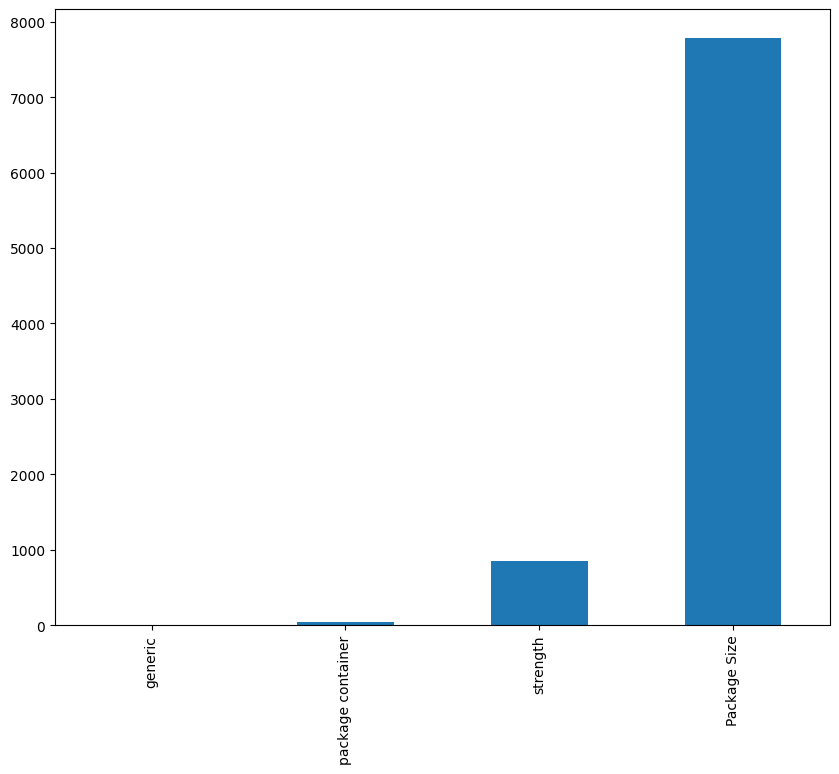

In [14]:
missing_value_describe(df_medicine)
print("Missing value analysis complete.")

#### Observation
> `Package Size` column has the highest number of missing values (~36%)

# **Visualization**

### Medicine Types

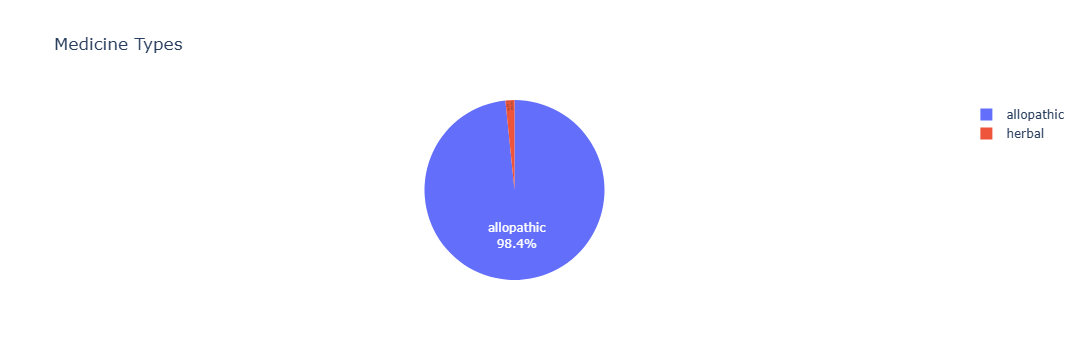

#### Huge gap between allopathic and herbal medicines

Plotted medicine types pie chart.


In [15]:
figure = px.pie(df_medicine['type'].value_counts().reset_index(), values='count', names='type', title='Medicine Types')
figure.update_traces(textposition='inside', textinfo='percent+label')
figure.show()
print_markdown("#### Huge gap between allopathic and herbal medicines")
print("Plotted medicine types pie chart.")

## Top Dosage Forms

### Utility Function

In [16]:
def most_frequent_plot(column_name, rows):
    df_frequency = df_medicine[column_name].value_counts().reset_index()
    df_frequency.columns = [column_name.title(), 'counts']
    df_frequency = df_frequency.head(rows)
    df_frequency['pct'] = df_frequency['counts'] / df_frequency['counts'].sum()
    df_frequency['count_pct'] = df_frequency['counts'].astype(str) + df_frequency['pct'].apply(lambda x: ' ({0:1.2f}%)'.format(x))

    figure = px.bar(df_frequency,
                x=column_name.title(),
                 y='counts', 
                 title='Most Frequent '+column_name.title(),
                 text='count_pct')
    figure.update_layout(yaxis_title="Count")
    figure.show()

print("Defined most_frequent_plot utility function.")

Defined most_frequent_plot utility function.


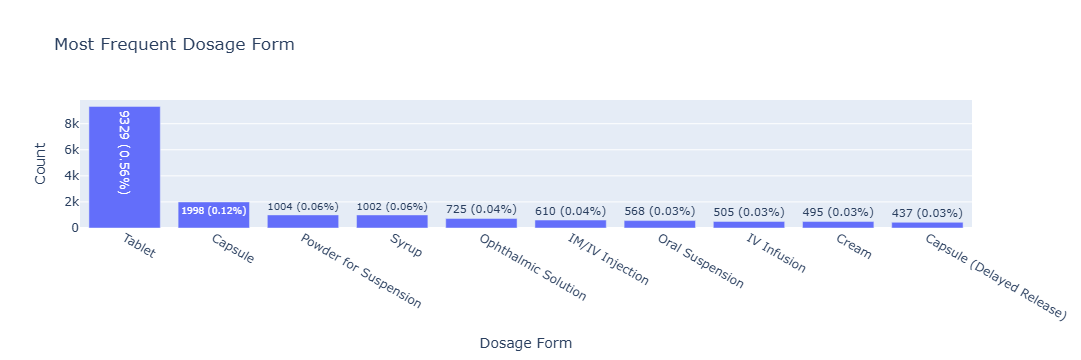

Plotted top 10 dosage forms.


In [17]:
column_name = 'dosage form'
most_frequent_plot(column_name, 10)
print("Plotted top 10 dosage forms.")

## Top Manufacturer

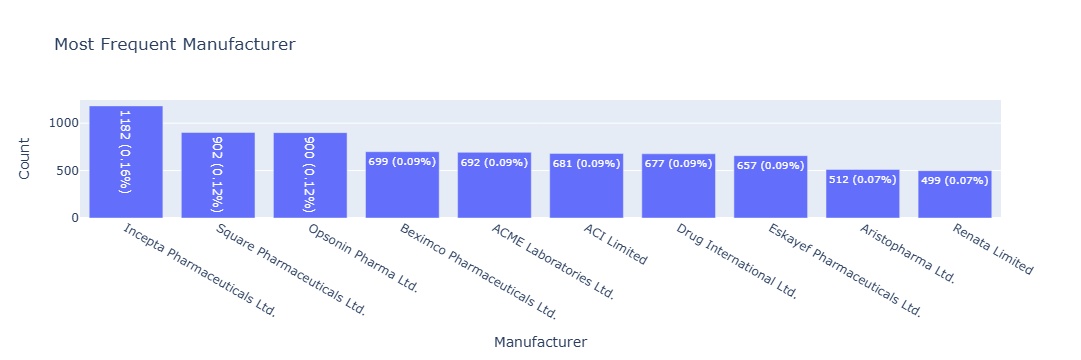

Plotted top 10 manufacturers.


In [18]:
column_name = 'manufacturer'
most_frequent_plot(column_name, 10)
print("Plotted top 10 manufacturers.")

## Top Generics

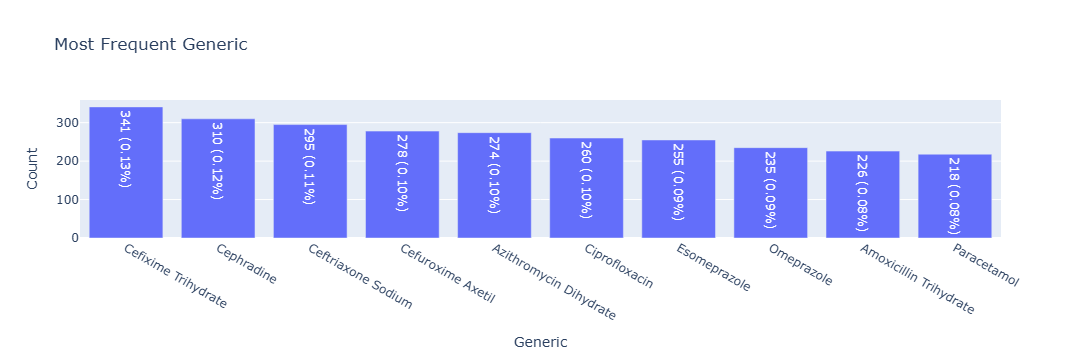

Plotted top 10 generics.


In [19]:
column_name = 'generic'
most_frequent_plot(column_name, 10)
print("Plotted top 10 generics.")

## Top Medicine Strength

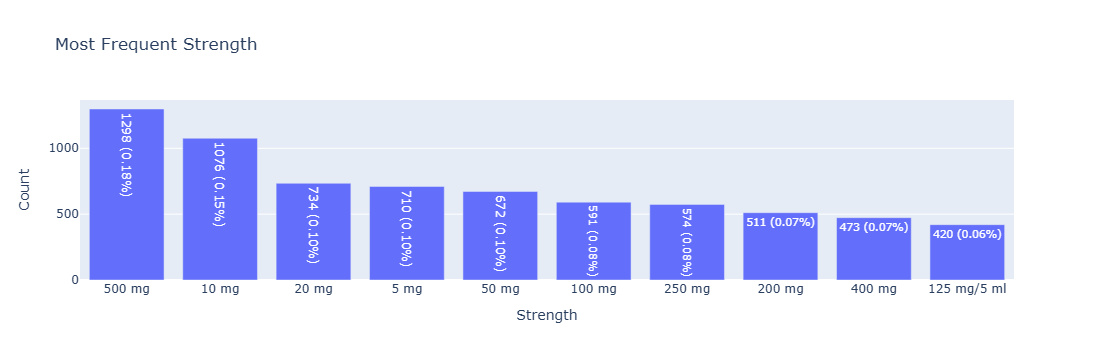

Plotted top 10 medicine strengths.


In [20]:
column_name = 'strength'
most_frequent_plot(column_name, 10)
print("Plotted top 10 medicine strengths.")

## Price

In [21]:
df_medicine[['dosage form', 'package container']].head(25)
# df_medicine['Package Size']

,dosage form,package container
0,Syrup,100 ml bottle: ৳ 40.12
1,Syrup,100 ml bottle: ৳ 100.00
2,Injection,"500 mg vial: ৳ 28.43,(5's pack: ৳ 142.15),"
3,Injection,"250 mg vial: ৳ 20.00,(5's pack: ৳ 100.00),"
4,Powder for Suspension,100 ml bottle: ৳ 45.00
5,Capsule,"Unit Price: ৳ 5.98,(100's pack: ৳ 598.00),"
6,Tablet,"Unit Price: ৳ 2.50,(20's pack: ৳ 50.00),"
7,Tablet,"Unit Price: ৳ 1.43,(100's pack: ৳ 143.00),"
8,Tablet,"Unit Price: ৳ 6.00,(50's pack: ৳ 300.00),"
9,Tablet,"Unit Price: ৳ 7.50,(30's pack: ৳ 225.00),"


### Data Cleaning

>Most of the medicines are tablet, soft gelatin, capsule and their variants and their pricing data have similar patterns that includes unit price. I will extract the unit price of these types of medicines.


In [22]:
# remove the null rows from the package size columns
df_medicineicine_with_package = df_medicine.dropna(subset=['Package Size'])
print(f"Removed null Package Size rows. Remaining: {df_medicineicine_with_package.shape[0]} rows.")

Removed null Package Size rows. Remaining: 13935 rows.


#### Overview of `Package Size` Values

In [23]:
df_medicineicine_with_package.head(8)

,brand name,type,dosage form,generic,strength,manufacturer,package container,Package Size
2,A-Clox,allopathic,Injection,Cloxacillin Sodium,500 mg/vial,ACME Laboratories Ltd.,"500 mg vial: ৳ 28.43,(5's pack: ৳ 142.15),",(5's pack: ৳ 142.15)
3,A-Clox,allopathic,Injection,Cloxacillin Sodium,250 mg/vial,ACME Laboratories Ltd.,"250 mg vial: ৳ 20.00,(5's pack: ৳ 100.00),",(5's pack: ৳ 100.00)
5,A-Clox,allopathic,Capsule,Cloxacillin Sodium,500 mg,ACME Laboratories Ltd.,"Unit Price: ৳ 5.98,(100's pack: ৳ 598.00),",(100's pack: ৳ 598.00)
6,A-Care,allopathic,Tablet,Betacarotene + Vitamin C + Vitamin E,6 mg+200 mg+50 mg,Asiatic Laboratories Ltd.,"Unit Price: ৳ 2.50,(20's pack: ৳ 50.00),",(20's pack: ৳ 50.00)
7,A-Card,allopathic,Tablet,Isosorbide Mononitrate,20 mg,ACME Laboratories Ltd.,"Unit Price: ৳ 1.43,(100's pack: ৳ 143.00),",(100's pack: ৳ 143.00)
8,A-Calm,allopathic,Tablet,Tolperisone Hydrochloride,50 mg,ACME Laboratories Ltd.,"Unit Price: ৳ 6.00,(50's pack: ৳ 300.00),",(50's pack: ৳ 300.00)
9,A-Cal DX,allopathic,Tablet,Calcium Carbonate [Elemental source] + Vitamin D3,500 mg+400 IU,ACME Laboratories Ltd.,"Unit Price: ৳ 7.50,(30's pack: ৳ 225.00),",(30's pack: ৳ 225.00)
10,A-Cal D,allopathic,Tablet,Calcium Carbonate [Elemental source] + Vitamin D3,500 mg+200 IU,ACME Laboratories Ltd.,"Unit Price: ৳ 6.50,(15's pack: ৳ 97.50),,Unit Price: ৳ 6...","(15's pack: ৳ 97.50),(30's pack: ৳ 195.00)"


In [24]:
df_medicineicine_with_package.tail(10)

,brand name,type,dosage form,generic,strength,manufacturer,package container,Package Size
21700,Zoxan,allopathic,Tablet,Nitazoxanide,500 mg,Opsonin Pharma Ltd.,"Unit Price: ৳ 10.07,(18's pack: ৳ 181.26),",(18's pack: ৳ 181.26)
21702,Zox,allopathic,Tablet,Nitazoxanide,500 mg,Square Pharmaceuticals Ltd.,"Unit Price: ৳ 10.07,(30's pack: ৳ 302.10),",(30's pack: ৳ 302.10)
21703,Zovia Teen G,allopathic,Tablet,Multivitamin & Multimineral [A-Z teen girls preparation],NaN,Opsonin Pharma Ltd.,"Unit Price: ৳ 6.00,(30's pack: ৳ 180.00),",(30's pack: ৳ 180.00)
21704,Zovia Teen B,allopathic,Tablet,Multivitamin & Multimineral [A-Z teen boys preparation],NaN,Opsonin Pharma Ltd.,"Unit Price: ৳ 6.00,(30's pack: ৳ 180.00),",(30's pack: ৳ 180.00)
21705,Zovia Silver,allopathic,Tablet,Multivitamin & Multimineral [A-Z silver preparation],NaN,Opsonin Pharma Ltd.,"Unit Price: ৳ 9.50,(30's pack: ৳ 285.00),,Unit Price: ৳ ...","(30's pack: ৳ 285.00),(60's pack: ৳ 570.00)"
21707,Zytix,allopathic,Tablet,Abiraterone Acetate,250 mg,Beacon Pharmaceuticals Ltd.,"Unit Price: ৳ 580.00,(6's pack: ৳ 3,480.00),","(6's pack: ৳ 3,480.00)"
21708,Zytiga,allopathic,Tablet,Abiraterone Acetate,250 mg,Janssen-Cilag,"Unit Price: ৳ 1,665.82,(120's pack: ৳ 199,898.40),","(120's pack: ৳ 199,898.40)"
21709,Zytec,allopathic,Tablet,Cetirizine Hydrochloride,10 mg,Desh Pharmaceuticals Ltd.,"Unit Price: ৳ 1.50,(100's pack: ৳ 150.00),",(100's pack: ৳ 150.00)
21711,Zymet Pro,allopathic,Capsule,Pancreatin,325 mg,Beximco Pharmaceuticals Ltd.,"Unit Price: ৳ 10.00,(90's pack: ৳ 900.00),,Unit Price: ৳...","(90's pack: ৳ 900.00),(60's pack: ৳ 600.00)"
21712,Zymet,allopathic,Tablet,Pancreatin,325 mg,Beximco Pharmaceuticals Ltd.,"Unit Price: ৳ 3.50,(100's pack: ৳ 350.00),",(100's pack: ৳ 350.00)


#### Insights


1. There are many cases where `Package Size` contains two or more values depending on the container.

> For example - check the 5th index row `Package Size`  value - `(15's pack: ৳ 97.50),(30's pack: ৳ 195.00)`

2. Also we have to watch out for the comma inside price value.

> For example - check the 4th index from bottom `Package Size`  value `(120's pack: ৳ 199,898.40)`


Therefore, we can split the column by applying a regex pattern **comma (,)** followed by **opening first bracket** and explode afterwards that will generate additional row/data points based on the `Package Size`. It counts as separate medicine (as product) 

In [25]:
df_medicineicine_with_package["Package Size"] = df_medicineicine_with_package["Package Size"].apply(lambda x: x.split(r',('))
print("Split Package Size column by comma-bracket pattern.")

Split Package Size column by comma-bracket pattern.


#### Splitted Data

In [26]:
df_medicineicine_with_package["Package Size"][:10]

2                           [(5's pack: ৳ 142.15)]
3                           [(5's pack: ৳ 100.00)]
5                         [(100's pack: ৳ 598.00)]
6                           [(20's pack: ৳ 50.00)]
7                         [(100's pack: ৳ 143.00)]
8                          [(50's pack: ৳ 300.00)]
9                          [(30's pack: ৳ 225.00)]
10    [(15's pack: ৳ 97.50), 30's pack: ৳ 195.00)]
11                        [(100's pack: ৳ 500.00)]
12                         [(100's pack: ৳ 86.00)]
Name: Package Size, dtype: object

In [27]:
df_medicineicine_with_package["Package Size"].tail(10)

21700                          [(18's pack: ৳ 181.26)]
21702                          [(30's pack: ৳ 302.10)]
21703                          [(30's pack: ৳ 180.00)]
21704                          [(30's pack: ৳ 180.00)]
21705    [(30's pack: ৳ 285.00), 60's pack: ৳ 570.00)]
21707                         [(6's pack: ৳ 3,480.00)]
21708                     [(120's pack: ৳ 199,898.40)]
21709                         [(100's pack: ৳ 150.00)]
21711    [(90's pack: ৳ 900.00), 60's pack: ৳ 600.00)]
21712                         [(100's pack: ৳ 350.00)]
Name: Package Size, dtype: object

#### Explode Multiple Medicines

**Based on Pack Size**

In [28]:
df_medicineicine_with_package = df_medicineicine_with_package.explode("Package Size").reset_index().drop(columns="index")
print(f"Exploded Package Size into separate rows. Total rows: {df_medicineicine_with_package.shape[0]}.")

Exploded Package Size into separate rows. Total rows: 14355.


In [29]:
df_medicineicine_with_package.tail(10)

,brand name,type,dosage form,generic,strength,manufacturer,package container,Package Size
14345,Zovia Teen G,allopathic,Tablet,Multivitamin & Multimineral [A-Z teen girls preparation],NaN,Opsonin Pharma Ltd.,"Unit Price: ৳ 6.00,(30's pack: ৳ 180.00),",(30's pack: ৳ 180.00)
14346,Zovia Teen B,allopathic,Tablet,Multivitamin & Multimineral [A-Z teen boys preparation],NaN,Opsonin Pharma Ltd.,"Unit Price: ৳ 6.00,(30's pack: ৳ 180.00),",(30's pack: ৳ 180.00)
14347,Zovia Silver,allopathic,Tablet,Multivitamin & Multimineral [A-Z silver preparation],NaN,Opsonin Pharma Ltd.,"Unit Price: ৳ 9.50,(30's pack: ৳ 285.00),,Unit Price: ৳ ...",(30's pack: ৳ 285.00)
14348,Zovia Silver,allopathic,Tablet,Multivitamin & Multimineral [A-Z silver preparation],NaN,Opsonin Pharma Ltd.,"Unit Price: ৳ 9.50,(30's pack: ৳ 285.00),,Unit Price: ৳ ...",60's pack: ৳ 570.00)
14349,Zytix,allopathic,Tablet,Abiraterone Acetate,250 mg,Beacon Pharmaceuticals Ltd.,"Unit Price: ৳ 580.00,(6's pack: ৳ 3,480.00),","(6's pack: ৳ 3,480.00)"
14350,Zytiga,allopathic,Tablet,Abiraterone Acetate,250 mg,Janssen-Cilag,"Unit Price: ৳ 1,665.82,(120's pack: ৳ 199,898.40),","(120's pack: ৳ 199,898.40)"
14351,Zytec,allopathic,Tablet,Cetirizine Hydrochloride,10 mg,Desh Pharmaceuticals Ltd.,"Unit Price: ৳ 1.50,(100's pack: ৳ 150.00),",(100's pack: ৳ 150.00)
14352,Zymet Pro,allopathic,Capsule,Pancreatin,325 mg,Beximco Pharmaceuticals Ltd.,"Unit Price: ৳ 10.00,(90's pack: ৳ 900.00),,Unit Price: ৳...",(90's pack: ৳ 900.00)
14353,Zymet Pro,allopathic,Capsule,Pancreatin,325 mg,Beximco Pharmaceuticals Ltd.,"Unit Price: ৳ 10.00,(90's pack: ৳ 900.00),,Unit Price: ৳...",60's pack: ৳ 600.00)
14354,Zymet,allopathic,Tablet,Pancreatin,325 mg,Beximco Pharmaceuticals Ltd.,"Unit Price: ৳ 3.50,(100's pack: ৳ 350.00),",(100's pack: ৳ 350.00)


#### Processing Unit Price

Replace all comma inside price value, like - `(120's pack: ৳ 199,898.40)` will turn to `(120's pack: ৳ 199898.40)`

In [30]:
df_medicineicine_with_package["Package Size"] = df_medicineicine_with_package["Package Size"].apply(lambda x:x.replace(',', ''))
print("Removed commas from price values in Package Size.")

Removed commas from price values in Package Size.


In [31]:
# https://stackoverflow.com/a/40840761/11105356
df_medicineicine_with_package['unit price'] = df_medicineicine_with_package['Package Size'].astype('str').str.extractall(r'(\d+(?:\.\d+)?)').groupby(level=0)[0].apply(list).apply(lambda x: float(x[1])/float(x[0]))
print("Extracted and calculated unit prices.")

Extracted and calculated unit prices.


**Checking the unit price**

In [32]:
df_medicineicine_with_package['unit price']

0          28.43
1          20.00
2           5.98
3           2.50
4           1.43
          ...   
14350    1665.82
14351       1.50
14352      10.00
14353      10.00
14354       3.50
Name: unit price, Length: 14355, dtype: float64

In [33]:
print_markdown(f"Most expensive medicine unit price - **{df_medicineicine_with_package['unit price'].max():.2f}** and least expensive unit price - **{df_medicineicine_with_package['unit price'].min():.2f}**")

Most expensive medicine unit price - **9090.29** and least expensive unit price - **0.09**

### Most Expensive Medicine

In [34]:
df_medicineicine_with_package.loc[df_medicineicine_with_package['unit price'].idxmax()]

brand name                                                       Omnitrope
type                                                            allopathic
dosage form                                                   SC Injection
generic                                                         Somatropin
strength                                                       5 mg/1.5 ml
manufacturer                                  SANDOZ (A Novartis Division)
package container    1.5 ml cartridge: ৳ 9,090.29,(5's pack: ৳ 45,451.45),
Package Size                                        (5's pack: ৳ 45451.45)
unit price                                                         9090.29
Name: 9306, dtype: object

### Most Frequent Price 

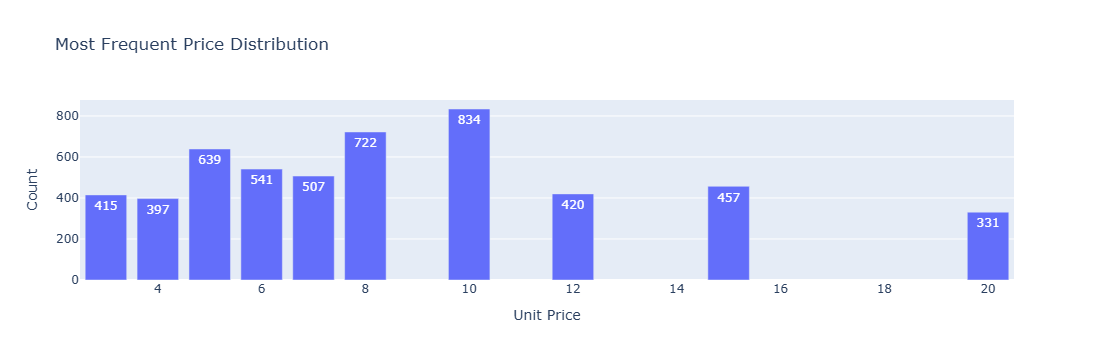

Plotted most frequent price distribution.


In [35]:
figure = px.bar(df_medicineicine_with_package['unit price'].value_counts().reset_index().rename(columns={'unit price':'Unit Price', 'count':'Count'}).head(10), 
                   x='Unit Price', y='Count',
                   title='Most Frequent Price Distribution',
                   text_auto=True)
figure.update_layout(yaxis_title="Count")
figure.update_traces(textposition='inside')
figure.show()
print("Plotted most frequent price distribution.")

> So unit price **BDT 10** is the most frequent price for medicines in Bangladesh

# **Generic**

In [36]:
df_generic = pd.read_csv('data/generic.csv', 
                         na_filter=False # ignoring the null values
                        )
print(f"Loaded generic.csv: {df_generic.shape[0]} rows, {df_generic.shape[1]} columns.")

Loaded generic.csv: 1711 rows, 22 columns.


In [37]:
df_generic.columns

Index(['generic id', 'generic name', 'slug', 'monograph link', 'drug class',
       'indication', 'indication description', 'therapeutic class description',
       'pharmacology description', 'dosage description',
       'administration description', 'interaction description',
       'contraindications description', 'side effects description',
       'pregnancy and lactation description', 'precautions description',
       'pediatric usage description', 'overdose effects description',
       'duration of treatment description', 'reconstitution description',
       'storage conditions description', 'descriptions count'],
      dtype='str')

In [38]:
# dropping id and slug columns as we won't be needing it for analysis
df_generic.drop(["generic id","slug"],axis=1, inplace=True)
print("Dropped 'generic id' and 'slug' columns from generic data.")

Dropped 'generic id' and 'slug' columns from generic data.


In [39]:
df_generic.head()

,generic name,monograph link,drug class,indication,indication description,therapeutic class description,pharmacology description,dosage description,administration description,interaction description,contraindications description,side effects description,pregnancy and lactation description,precautions description,pediatric usage description,overdose effects description,duration of treatment description,reconstitution description,storage conditions description,descriptions count
0,Adalimumab,https://medex.com.bd/attachments/FgGWUFrlD7LThDOJE9ArMGq...,Immunosuppressant,Ulcerative colitis,"<div class=""ac-body""><div class=""min-str-block""><div cla...","<div class=""ac-body"">Disease-modifying antirheumatic dru...","<div class=""ac-body"">Adalimumab is a recombinant human I...","<div class=""ac-body""><strong>Rheumatoid Arthritis, Psori...","<div class=""ac-body"">Administered by subcutaneous inject...","<div class=""ac-body"">Abatacept: Increased risk of seriou...","<div class=""ac-body"">Adalimumab should not be administer...","<div class=""ac-body"">The most common adverse reaction wi...","<div class=""ac-body"">Pregnancy Category B. Adequate and ...","<div class=""ac-body""><ul>\r\n<li><strong>Serious infecti...","<div class=""ac-body""><strong>Pediatric Use</strong>: Saf...","<div class=""ac-body"">The maximum tolerated dose of Adali...",,,"<div class=""ac-body"">Do not use beyond the expiration da...",13
1,Acyclovir + Hydrocortisone,https://medex.com.bd/attachments/hmi4dt8aYaBubgZ8AkKxlsm...,Hydrocortisone & Combined preparations,Herpes labialis,"<div class=""ac-body"">Acyclovir &amp; Hydrocortisone Crea...","<div class=""ac-body"">Hydrocortisone &amp; Combined prepa...","<div class=""ac-body"">Acyclovir is a synthetic purine nuc...","<div class=""ac-body"">The cream should be topically appli...",,,"<div class=""ac-body"">There is no known contraindication....","<div class=""ac-body"">The following most common adverse r...","<div class=""ac-body"">Pregnancy Category B. There are no ...","<div class=""ac-body"">Acyclovir and Hydrocortisone should...","<div class=""ac-body"">Safety and effectiveness in pediatr...",,,,"<div class=""ac-body"">Keep below 30°C temperature, away f...",10
2,Acyclovir (Topical),https://medex.com.bd/attachments/ENyoYKzQq8b7VMZE4lELf5n...,Topical Antiviral preparations,Sore lips,"<div class=""ac-body"">Acyclovir cream is a herpes simplex...","<div class=""ac-body"">Topical Antiviral preparations</div>","<div class=""ac-body"">Acyclovir is an antiviral drug acti...","<div class=""ac-body"">Acyclovir cream should be applied f...",,"<div class=""ac-body"">Clinical experience has identified ...","<div class=""ac-body"">Acyclovir cream is contraindicated ...","<div class=""ac-body"">The most common adverse reactions a...","<div class=""ac-body"">Pregnancy Category B. There are no ...","<div class=""ac-body"">Acyclovir cream should only be appl...","<div class=""ac-body""><strong>Pediatric Use</strong>: An ...",,,,"<div class=""ac-body"">Store Acyclovir cream at room tempe...",11
3,Acyclovir (Oral),https://medex.com.bd/attachments/zVc7h4TgucYev3wdbHFLiqL...,Herpes simplex & Varicella-zoster virus infections,Varicella zoster (chickenpox),"<div class=""ac-body"">Aciclovir is indicated for-<br>\r\n...","<div class=""ac-body"">Herpes simplex &amp; Varicella-zost...","<div class=""ac-body"">Aciclovir is a synthetic purine der...","<div class=""ac-body"">Treatment of initial herpes simplex...",,"<div class=""ac-body"">Probenecid reduces Aciclovir excret...","<div class=""ac-body"">Aciclovir is contraindicated in pat...","<div class=""ac-body"">Rash, gastrointestinal disturbance,...","<div class=""ac-body"">Pregnancy category B. Aciclovir sho...","<div class=""ac-body"">Aciclovir should be administered wi...",,,,,"<div class=""ac-body"">Should be stored below 25°C. It sho...",10
4,Acyclovir (Ophthalmic),https://medex.com.bd/attachments/Kz5fDjxpm2VFnag8dQCT5Zh...,Ophthalmic Anti-viral Products,Neonatal Conjunctivit

### Observation
> Columns with description (`indication description`, `dosage description` .... `storage conditions description`) are written in `HTML`

> We can parse those HTML files and convert them to text using `BeautifulSoup` package

## Parse HTML

In [40]:
df_generic["indication description"] = df_generic["indication description"].apply(lambda x: BeautifulSoup(x).get_text().replace(chr(10)," "))
print("Parsed HTML from indication descriptions.")
df_generic["indication description"].head()

Parsed HTML from indication descriptions.


0    Adalimumab is a tumor necrosis factor (TNF) blocker indi...
1    Acyclovir & Hydrocortisone Cream is indicated for the ea...
2    Acyclovir cream is a herpes simplex virus (HSV) nucleosi...
3    Aciclovir is indicated for-  The treatment of viral infe...
4    Acyclovir is indicated for the treatment of Herpes simpl...
Name: indication description, dtype: str

# **Manufacturer**

In [41]:
df_manufacturer = pd.read_csv('data/manufacturer.csv', encoding='utf-8')
df_manufacturer.drop(["manufacturer id","slug"],axis=1, inplace=True)

df_manufacturer.head()
print(f"Loaded manufacturer.csv and dropped id/slug columns. {df_manufacturer.shape[0]} rows.")

Loaded manufacturer.csv and dropped id/slug columns. 240 rows.


In [42]:
print_markdown(f"There are **{df_manufacturer.shape[0]}** Pharmaceutical Companies")

There are **240** Pharmaceutical Companies

## Medicine Selling Distribution

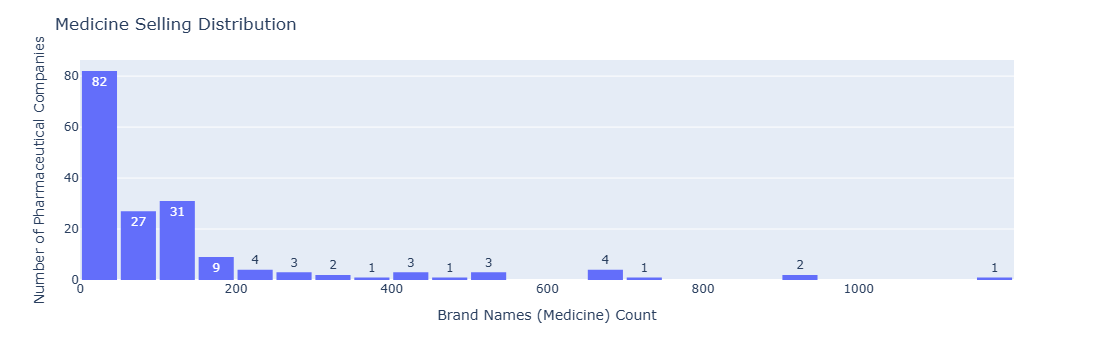

Plotted medicine selling distribution histogram.


In [43]:
figure = px.histogram(df_manufacturer, x="brand names count", text_auto=True)

figure.update_layout(
    title_text='Medicine Selling Distribution', # title of plot
    xaxis_title_text='Brand Names (Medicine) Count', # xaxis label
    yaxis_title_text='Number of Pharmaceutical Companies', # yaxis label
    bargap=0.05, # gap between bars of adjacent location coordinates
    bargroupgap=0.05 # gap between bars of the same location coordinates
)
figure.show()
print("Plotted medicine selling distribution histogram.")

### Observation
> Most of the pharmaceutical companies sell less than 100 different types of brand names

> Don't confuse medicine with brand names, different companies sell same generic medicine under different names.
Example - **`Paracetamol`** generic is sold as **`Napa`** by **`Beximco Pharmaceuticals Ltd.`** and **`Ace`** by **`Square Pharmaceuticals Ltd.`**

## Generic Distribution

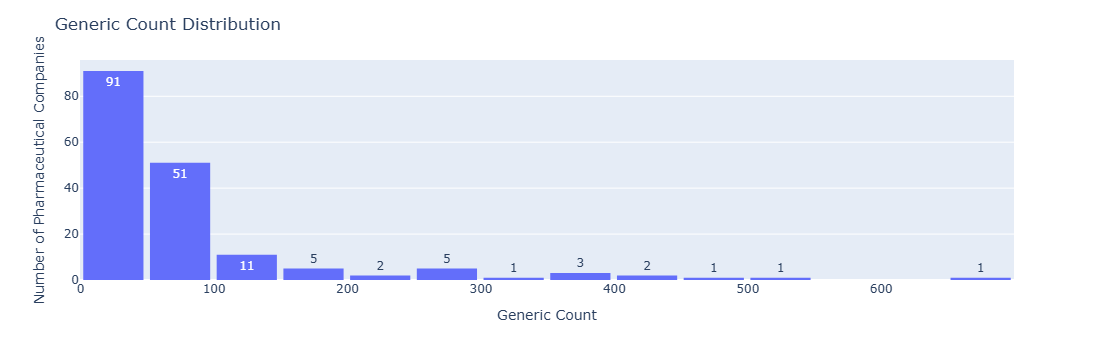

Plotted generic count distribution histogram.


In [44]:
figure = px.histogram(df_manufacturer, x="generics count", text_auto=True)

figure.update_layout(
    title_text='Generic Count Distribution', # title of plot
    xaxis_title_text='Generic Count', # xaxis label
    yaxis_title_text='Number of Pharmaceutical Companies', # yaxis label
    bargap=0.05, # gap between bars of adjacent location coordinates
    bargroupgap=0.05 # gap between bars of the same location coordinates
)
figure.show()
print("Plotted generic count distribution histogram.")

## Top Pharmaceutical Company

In [45]:
df_manufacturer.loc[df_manufacturer['brand names count'].idxmax()]
print("Displayed top pharmaceutical company by brand names count.")

Displayed top pharmaceutical company by brand names count.


In [46]:
df_manufacturer.loc[df_manufacturer['generics count'].idxmax()]
print("Displayed top pharmaceutical company by generics count.")

Displayed top pharmaceutical company by generics count.


> ###  **`Incepta Pharmaceuticals Ltd.`** is the top seller in terms of generic as well as medicines/brand Names!!!

# **Dosage Form**

In [47]:
df_dosage = pd.read_csv('data/dosage form.csv', encoding='utf-8')
print(f"Loaded dosage form.csv: {df_dosage.shape[0]} rows, {df_dosage.shape[1]} columns.")

Loaded dosage form.csv: 113 rows, 4 columns.


In [48]:
df_dosage.columns

Index(['dosage form id', 'dosage form name', 'slug', 'brand names count'], dtype='str')

In [49]:
df_dosage.drop(["dosage form id","slug"],axis=1, inplace=True)

df_dosage.head()
print("Dropped id/slug columns from dosage form data.")

Dropped id/slug columns from dosage form data.


In [50]:
df_dosage.loc[df_dosage['brand names count'].idxmax()]
print("Displayed most common dosage form.")

Displayed most common dosage form.


> ###  Most types of medicines are **`Tablet`**

# **Drug Class**

In [51]:
df_drug_class = pd.read_csv('data/drug class.csv', encoding='utf-8')
print(f"Loaded drug class.csv: {df_drug_class.shape[0]} rows, {df_drug_class.shape[1]} columns.")

Loaded drug class.csv: 453 rows, 4 columns.


In [52]:
df_drug_class.columns

Index(['drug class id', 'drug class name', 'slug', 'generics count'], dtype='str')

In [53]:
df_drug_class.drop(["drug class id","slug"],axis=1, inplace=True)

df_drug_class.head()
print("Dropped id/slug columns from drug class data.")

Dropped id/slug columns from drug class data.


In [54]:
df_drug_class.loc[df_drug_class['generics count'].idxmax()]
print("Displayed top drug class by generics count.")

Displayed top drug class by generics count.


> ### Top Drug Class in terms of generic is **`Herbal and Nutraceuticals`** 

## Drug Class WordCloud

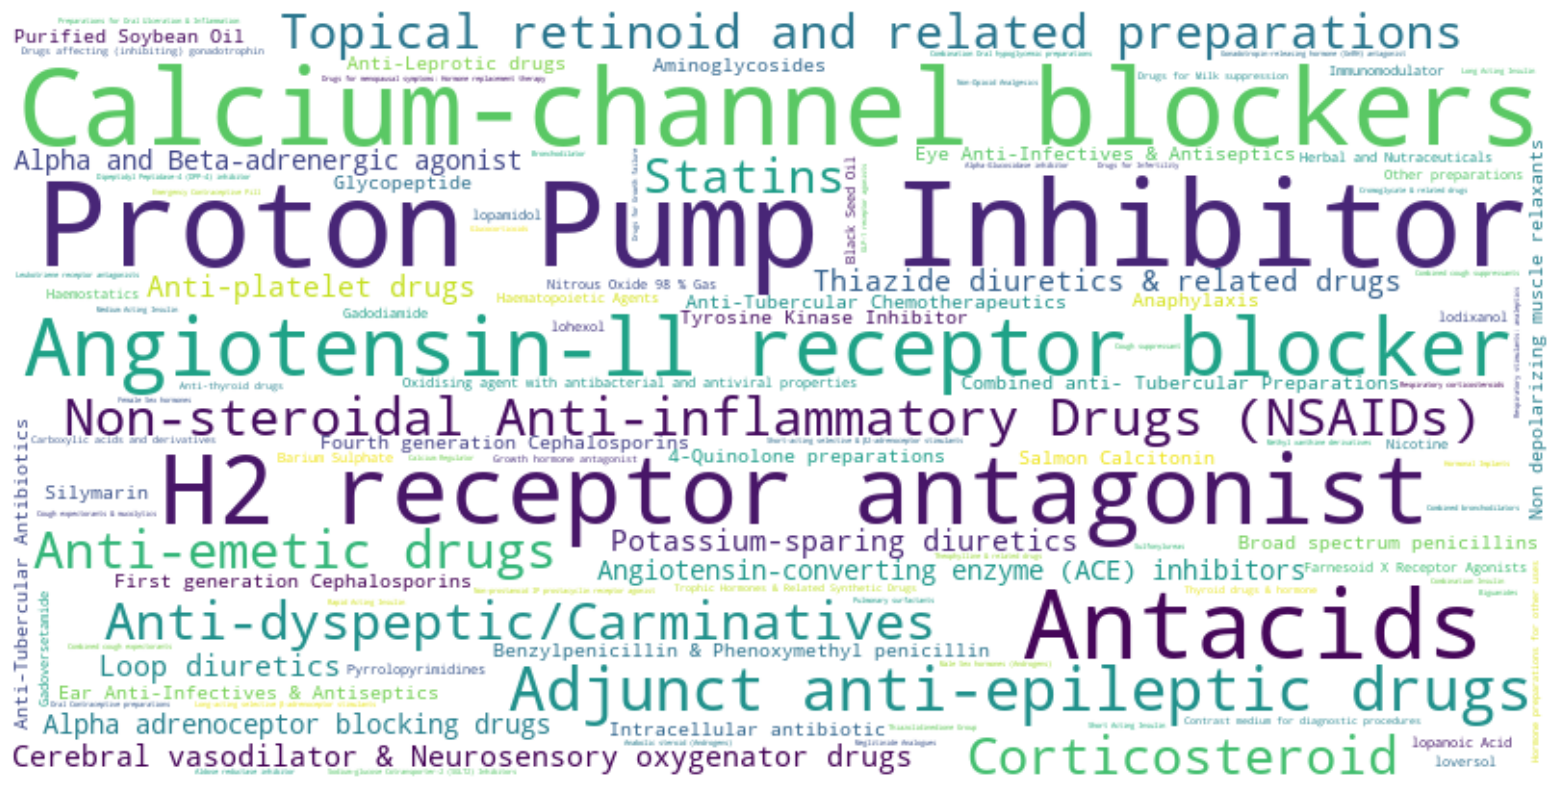

### These are the Most Frequent Drug Classes

Generated and saved drug class word cloud.


In [55]:
frequency_data = df_drug_class['drug class name'].value_counts().to_dict()

wordcloud = WordCloud(width=800, height=400,background_color="white", max_font_size=300).generate_from_frequencies(frequency_data)
plt.figure(figsize=(20,10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

wordcloud.to_file("drug_class_word_cloud.png")

print_markdown("### These are the Most Frequent Drug Classes")
print("Generated and saved drug class word cloud.")

# **Indication**

In [56]:
df_indication = pd.read_csv('data/indication.csv', encoding='utf-8')
print(f"Loaded indication.csv: {df_indication.shape[0]} rows, {df_indication.shape[1]} columns.")

Loaded indication.csv: 2043 rows, 4 columns.


In [57]:
df_indication.columns

Index(['indication id', 'indication name', 'slug', 'generics count'], dtype='str')

In [58]:
df_indication.drop(["indication id","slug"],axis=1, inplace=True)

df_indication.head()
print("Dropped id/slug columns from indication data.")

Dropped id/slug columns from indication data.


In [59]:
df_indication.loc[df_indication['generics count'].idxmax()]
print("Displayed most common indication by generics count.")

Displayed most common indication by generics count.


> #### `Hypertension` is common indication for most generics

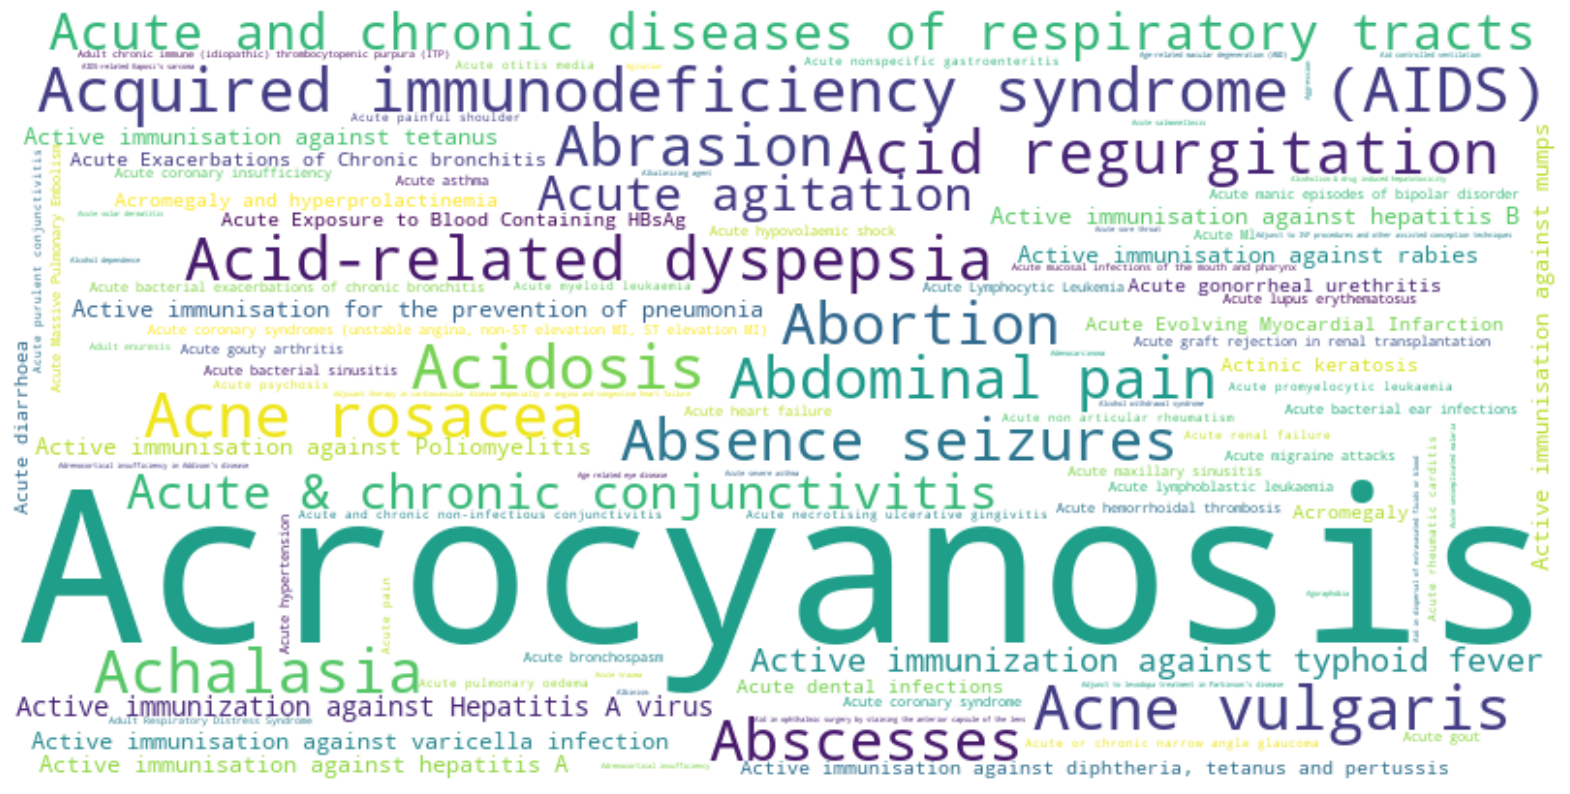

### These are the Most Frequent Indications

Generated and saved indication word cloud.


In [60]:
frequency_data = df_indication['indication name'].value_counts().to_dict()

wordcloud = WordCloud(width=800, height=400,background_color="white", max_font_size=300).generate_from_frequencies(frequency_data)
plt.figure(figsize=(20,12))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

wordcloud.to_file("indication_name_word_cloud.png")

print_markdown("### These are the Most Frequent Indications")
print("Generated and saved indication word cloud.")

# **Conclusion**

In this notebook, I explored the Assorted Medicine Dataset of Bangladesh to practice and demonstrate key data analysis skills including:

- **Pandas** — data loading, cleaning, transformation, grouping, value counts, handling missing values, string operations, and exploding columns
- **Matplotlib** — bar charts for missing value analysis and word cloud rendering
- **Plotly** — interactive pie charts, bar charts, and histograms
- **WordCloud** — visual frequency analysis of drug classes and indications
- **BeautifulSoup** — parsing HTML content from description columns

There is plenty of room for improvement. A possible TODO list:

- Extract `Price` for all possible medicine entries
- Extract pack size and pack container for all possible medicine entries
- Further analysis of Generic descriptions
- Further analysis of Indications and drug classes
- Validation of count features from `Indication`, `Drug Class`, `Dosage Form` and `Manufacturer` by using their respective names with `Medicine` and `Generic` dataset